In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

RAW            = '../data/tram_2025-07-28_2025-08-03.parquet'
DROP_THRESHOLD = 100

## 1. 读数据，计算速度

In [2]:
df = (
    pl.read_parquet(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'tuerkriterium'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns([
        pl.int_range(pl.len()).over('fzg_id').alias('row_idx'),
        pl.col('distanz').diff().over('fzg_id').alias('delta'),
        pl.col('tst_iso').diff().over('fzg_id').dt.total_seconds().alias('dt'),
    ])
    .with_columns(
        pl.when(pl.col('delta') < -DROP_THRESHOLD)
            .then(pl.lit(-1.0))
        .when(pl.col('delta') < 0)
            .then(pl.lit(None))
        .when(pl.col('dt').is_null() | (pl.col('dt') == 0))
            .then(pl.lit(None))
        .otherwise(
            pl.col('delta') / pl.col('dt')
        )
        .alias('speed_ms')
    )
)

print(f'Total rows: {len(df):,}  |  Vehicles: {df["fzg_id"].n_unique()}')
print()
print('speed_ms 分类计数：')
print(f'  到站 drop（= -1）:  {(df["speed_ms"] == -1).sum():>10,}')
print(f'  噪声（NaN）:        {df["speed_ms"].is_null().sum():>10,}')
print(f'  正常行（>= 0）:     {(df["speed_ms"] >= 0).sum():>10,}')

Total rows: 4,980,084  |  Vehicles: 169

speed_ms 分类计数：
  到站 drop（= -1）:     465,690
  噪声（NaN）:           214,105
  正常行（>= 0）:      4,300,289


## 2. 速度分布

=== 正常行速度分布（m/s）===
  p0  :    0.000 m/s
  p25 :    0.000 m/s
  p50 :    2.062 m/s
  p75 :    8.500 m/s
  p90 :   13.333 m/s
  p95 :   17.000 m/s
  p99 :   46.000 m/s
  p100: 1112.000 m/s
  stationary (speed==0): 1,955,480  (45.5%)


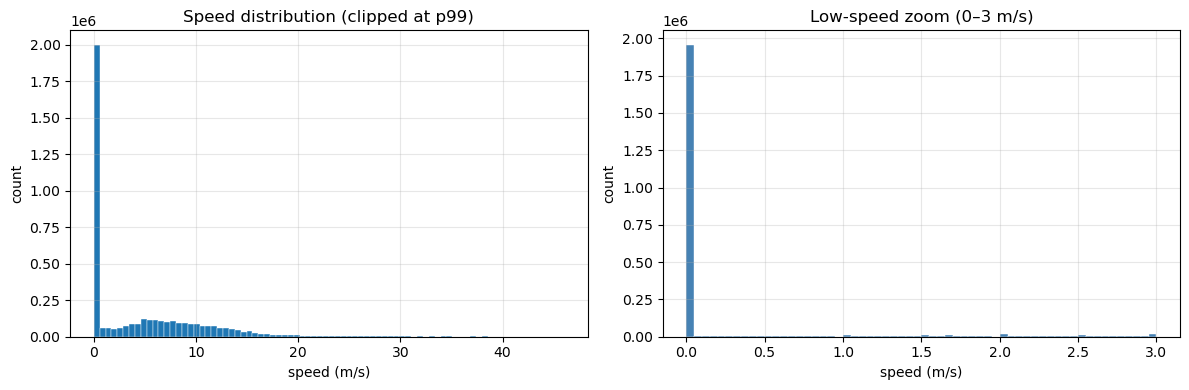

In [3]:
normal_speed = df.filter(pl.col('speed_ms') >= 0)['speed_ms'].to_numpy()

print('=== 正常行速度分布（m/s）===')
for p in [0, 25, 50, 75, 90, 95, 99, 100]:
    print(f'  p{p:<3d}: {np.percentile(normal_speed, p):>8.3f} m/s')
print(f'  stationary (speed==0): {(normal_speed == 0).sum():,}  ({(normal_speed == 0).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clip = np.percentile(normal_speed, 99)
axes[0].hist(normal_speed[normal_speed <= clip], bins=80,
             edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('speed (m/s)')
axes[0].set_ylabel('count')
axes[0].set_title('Speed distribution (clipped at p99)')
axes[0].grid(alpha=0.3)

low = normal_speed[normal_speed <= 3]
axes[1].hist(low, bins=60, edgecolor='white', linewidth=0.3, color='steelblue')
axes[1].set_xlabel('speed (m/s)')
axes[1].set_ylabel('count')
axes[1].set_title('Low-speed zoom (0–3 m/s)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 门事件 vs 速度

验证强约束：开门（0→1）和关门（1→0）是否都发生在车辆静止时。

In [4]:
door_events = df.with_columns([
    (
        (pl.col('tuerkriterium').shift(1).over('fzg_id') == False) &
        (pl.col('tuerkriterium') == True)
    ).alias('is_open'),
    (
        (pl.col('tuerkriterium').shift(1).over('fzg_id') == True) &
        (pl.col('tuerkriterium') == False)
    ).alias('is_close'),
])

opens_raw  = door_events.filter(pl.col('is_open'))['speed_ms'].to_numpy()
closes_raw = door_events.filter(pl.col('is_close'))['speed_ms'].to_numpy()

opens  = opens_raw[~np.isnan(opens_raw.astype(float))]
closes = closes_raw[~np.isnan(closes_raw.astype(float))]
opens  = opens.astype(float)
closes = closes.astype(float)

for label, raw, arr in [('开门（0→1）', opens_raw, opens), ('关门（1→0）', closes_raw, closes)]:
    arr = arr.astype(float)
    print(f'=== {label} speed_ms 分布 ===')
    print(f'  总计:             {len(raw):,}')
    print(f'  在到站drop行(-1): {(raw == -1).sum():,}  ({np.nanmean(raw == -1)*100:.1f}%)')
    print(f'  speed = 0:        {(arr == 0).sum():,}  ({(arr == 0).mean()*100:.1f}%)')
    print(f'  speed > 0:        {(arr > 0).sum():,}  ({(arr > 0).mean()*100:.1f}%)')
    pos = arr[arr > 0]
    if len(pos) > 0:
        print(f'  speed>0 中位数:   {np.median(pos):.3f} m/s')
    print()

=== 开门（0→1） speed_ms 分布 ===
  总计:             410,769
  在到站drop行(-1): 133,560  (32.5%)
  speed = 0:        30,292  (8.4%)
  speed > 0:        195,722  (54.4%)
  speed>0 中位数:   4.000 m/s

=== 关门（1→0） speed_ms 分布 ===
  总计:             410,877
  在到站drop行(-1): 269,592  (65.6%)
  speed = 0:        1,776  (0.4%)
  speed > 0:        126,281  (31.8%)
  speed>0 中位数:   2.500 m/s



/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/126174520.py:15: UserWarning: Glyph 24320 (\N{CJK UNIFIED IDEOGRAPH-5F00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/126174520.py:15: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/126174520.py:15: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/126174520.py:15: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/126174520.py:15: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx

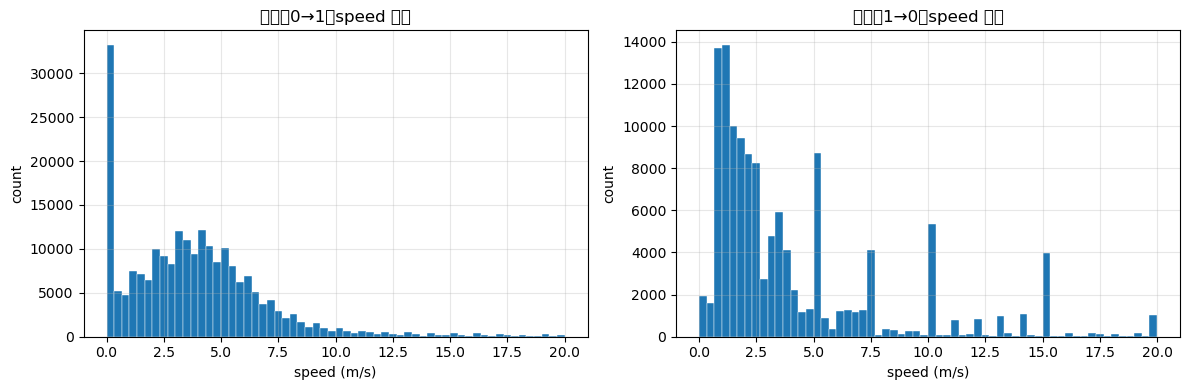

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, arr, title in [
    (axes[0], opens[opens >= 0],   '开门（0→1）speed 分布'),
    (axes[1], closes[closes >= 0], '关门（1→0）speed 分布'),
]:
    arr = arr.astype(float)
    clip = min(np.percentile(arr, 99), 20) if len(arr) > 0 else 5
    ax.hist(arr[arr <= clip], bins=60, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('speed (m/s)')
    ax.set_ylabel('count')
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 单个停站可视化：speed + tuerkriterium 时间轴

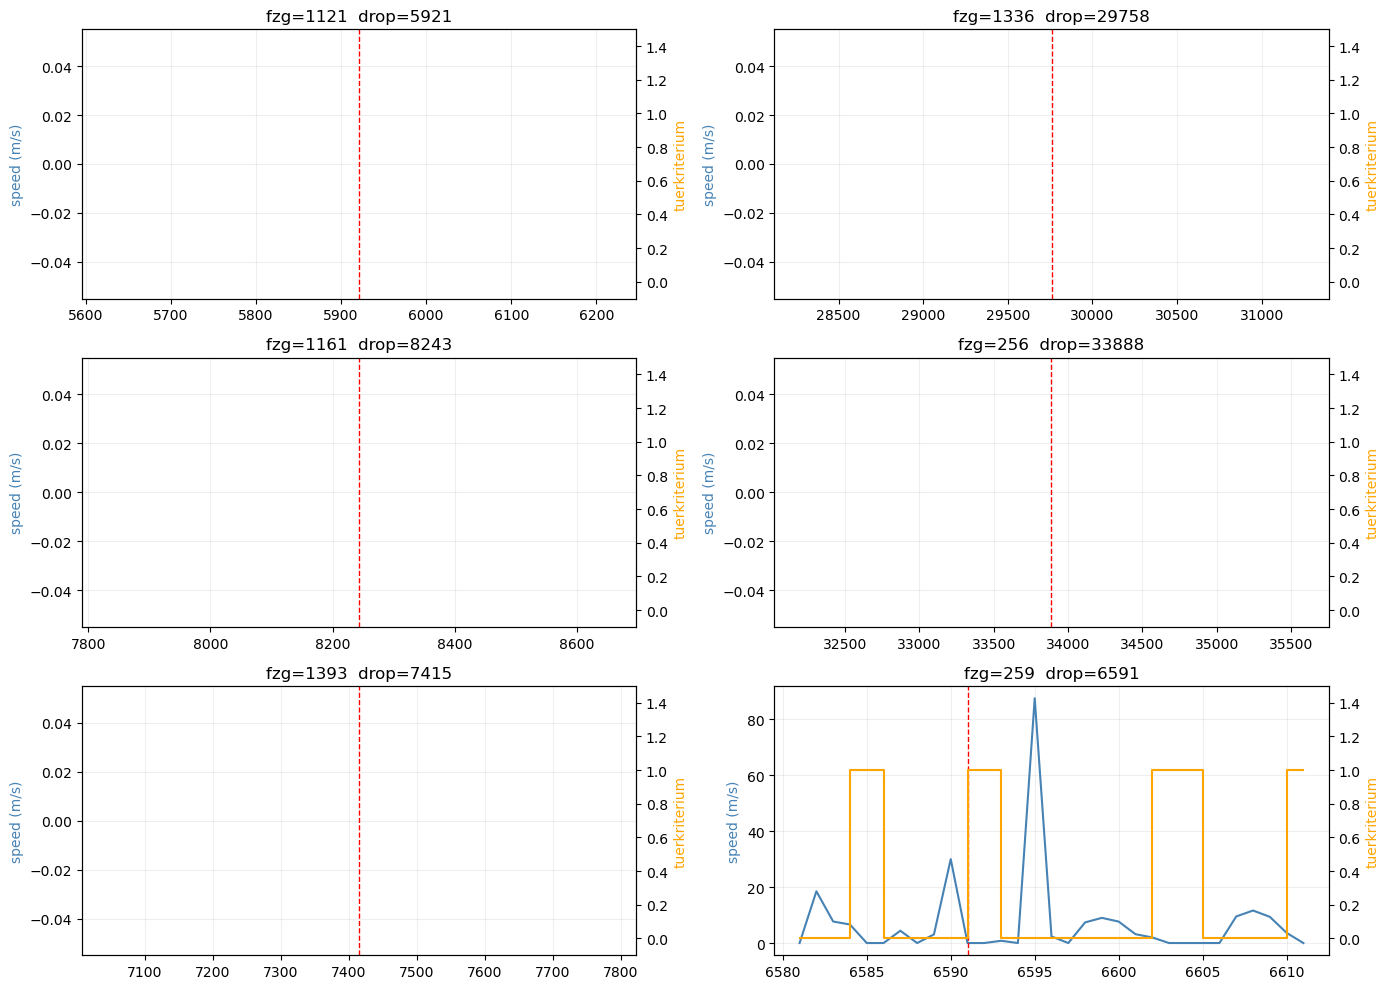

In [6]:
stop_events = pl.read_parquet('../data/processed/core_stop_events.parquet')

sample = (
    stop_events
    .filter(pl.col('stop_status') == 'normal')
    .filter(pl.col('dwell_time') > 5)
    .sample(6, seed=0)
)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, row in zip(axes, sample.iter_rows(named=True)):
    vid          = row['fzg_id']
    drop_row_idx = row['drop_row_idx']

    win = (
        df.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(drop_row_idx - 10, drop_row_idx + 20))
        .sort('row_idx')
    )

    t     = win['row_idx'].to_numpy()
    speed = win['speed_ms'].to_numpy().astype(float)
    door  = win['tuerkriterium'].to_numpy().astype(float)

    speed_plot = np.where(np.isnan(speed) | (speed < 0), 0, speed)

    ax2 = ax.twinx()
    ax.plot(t, speed_plot, color='steelblue', label='speed (m/s)', linewidth=1.5)
    ax2.step(t, door, color='orange', label='door (1=open)', linewidth=1.5, where='post')
    ax.axvline(drop_row_idx, color='red', linestyle='--', linewidth=1, label='drop')

    ax.set_ylabel('speed (m/s)', color='steelblue')
    ax2.set_ylabel('tuerkriterium', color='orange')
    ax2.set_ylim(-0.1, 1.5)
    ax.set_title(f'fzg={vid}  drop={drop_row_idx}')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5. 静止段定义与持续时间

=== 静止段持续时间（秒）===
  p25 :      3.0 s
  p50 :     10.0 s
  p75 :     15.0 s
  p90 :     30.0 s
  p95 :     54.0 s
  p99 :    519.0 s

=== 静止段行数 ===
  p25 :      1.0 rows
  p50 :      1.0 rows
  p75 :      1.0 rows
  p90 :      3.0 rows
  p95 :      4.0 rows
  p99 :     37.0 rows


/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/1439351905.py:43: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/1439351905.py:43: UserWarning: Glyph 27490 (\N{CJK UNIFIED IDEOGRAPH-6B62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/1439351905.py:43: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/1439351905.py:43: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11319/1439351905.py:43: UserWarning: Glyph 32493 (\N{CJK UNIFIED IDEOGRAPH-7EED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcf

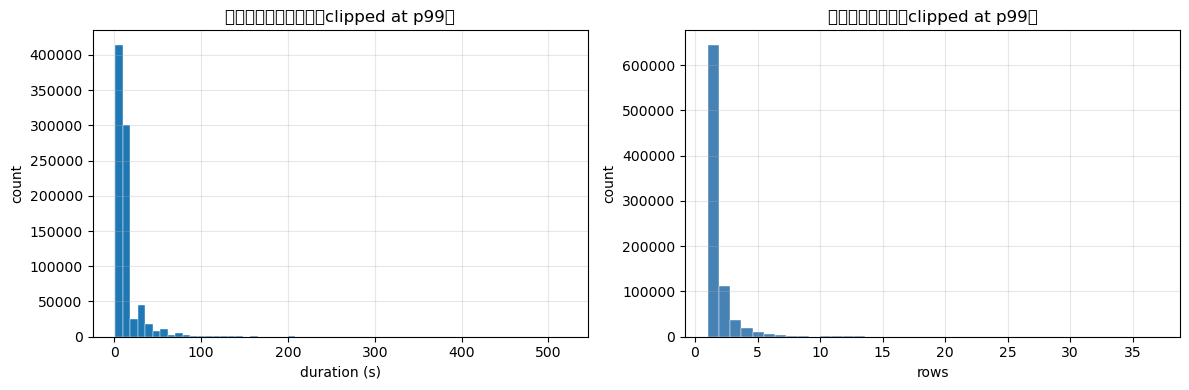

In [7]:
stationary = (
    df
    .with_columns(
        (pl.col('speed_ms') != 0).cast(pl.Int32)
        .cum_sum().over('fzg_id')
        .alias('stationary_segment')
    )
    .filter(pl.col('speed_ms') == 0)
    .group_by(['fzg_id', 'stationary_segment'])
    .agg([
        pl.len().alias('n_rows'),
        pl.col('dt').sum().alias('duration_sec'),
    ])
)

dur  = stationary['duration_sec'].drop_nulls().to_numpy()
rows = stationary['n_rows'].to_numpy()

print('=== 静止段持续时间（秒）===')
for p in [25, 50, 75, 90, 95, 99]:
    print(f'  p{p:<3d}: {np.percentile(dur, p):>8.1f} s')
print()
print('=== 静止段行数 ===')
for p in [25, 50, 75, 90, 95, 99]:
    print(f'  p{p:<3d}: {np.percentile(rows, p):>8.1f} rows')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dur_clip = dur[dur <= np.percentile(dur, 99)]
axes[0].hist(dur_clip, bins=60, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('duration (s)')
axes[0].set_ylabel('count')
axes[0].set_title('静止段持续时长分布（clipped at p99）')
axes[0].grid(alpha=0.3)

rows_clip = rows[rows <= np.percentile(rows, 99)]
axes[1].hist(rows_clip, bins=40, edgecolor='white', linewidth=0.3, color='steelblue')
axes[1].set_xlabel('rows')
axes[1].set_ylabel('count')
axes[1].set_title('静止段行数分布（clipped at p99）')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()